# Several panels, one question each

When two measurements do not share a unit, they do not share an axis. Give each measurement its own panel. Align the panels on the thing they do share, such as the day.

Five days in the same reactor:

| Day | Temperature (C) | Pressure (kPa) |
|---:|---:|---:|
| 1 | 16 | 101 |
| 2 | 18 | 100 |
| 3 | 17 | 103 |
| 4 | 21 | 104 |
| 5 | 20 | 102 |

Day-to-day changes:

$$
\begin{aligned}
\text{temperature} &\colon +2,\ -1,\ +4,\ -1 \\
\text{pressure} &\colon -1,\ +3,\ +1,\ -2
\end{aligned}
$$

From day $1$ to day $2$, temperature rose and pressure fell. They are not the same event drawn twice. They do share one fact: both series reach their maximum on day $4$, at $21\,\text{C}$ and $104\,\text{kPa}$.


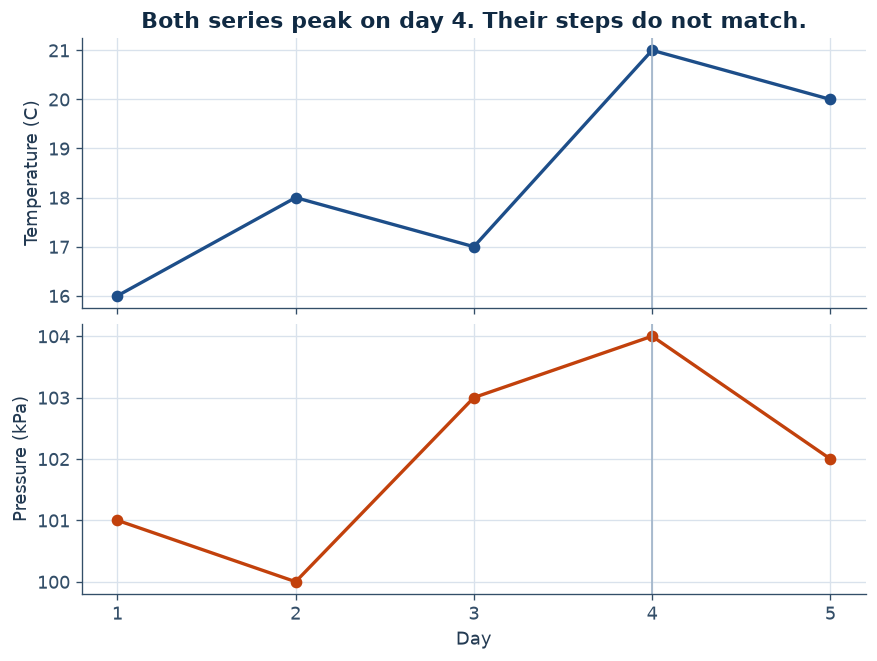

In [1]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Two panels, one shared day axis, two different units.
days = [1, 2, 3, 4, 5]
temperature = [16, 18, 17, 21, 20]
pressure = [101, 100, 103, 104, 102]
temp_steps = [temperature[i + 1] - temperature[i] for i in range(4)]
pressure_steps = [pressure[i + 1] - pressure[i] for i in range(4)]
assert temp_steps == [2, -1, 4, -1]
assert pressure_steps == [-1, 3, 1, -2]
assert temperature.index(max(temperature)) == 3
assert pressure.index(max(pressure)) == 3
fig, panels = plt.subplots(2, 1, sharex=True, constrained_layout=True, figsize=(7.2, 5.4))
panels[0].plot(days, temperature, color=BLUE, marker="o", linewidth=2)
panels[0].set_ylabel("Temperature (C)")
panels[0].set_title("Both series peak on day 4. Their steps do not match.")
panels[1].plot(days, pressure, color=CLAY, marker="o", linewidth=2)
panels[1].set_ylabel("Pressure (kPa)")
panels[1].set_xlabel("Day")
for panel in panels:
    panel.axvline(4, color=GRAY, linewidth=1)
    panel.set_xticks(days)


## The lab week, split by question

The North Lab week supports two questions, so it gets two panels. The left panel is the daily speedup, $18$ to $26$ by steps of $2$. The right panel is the ranking, Alan $20$ through Grace $34$. The panels are not interchangeable. One is time. The other is people.


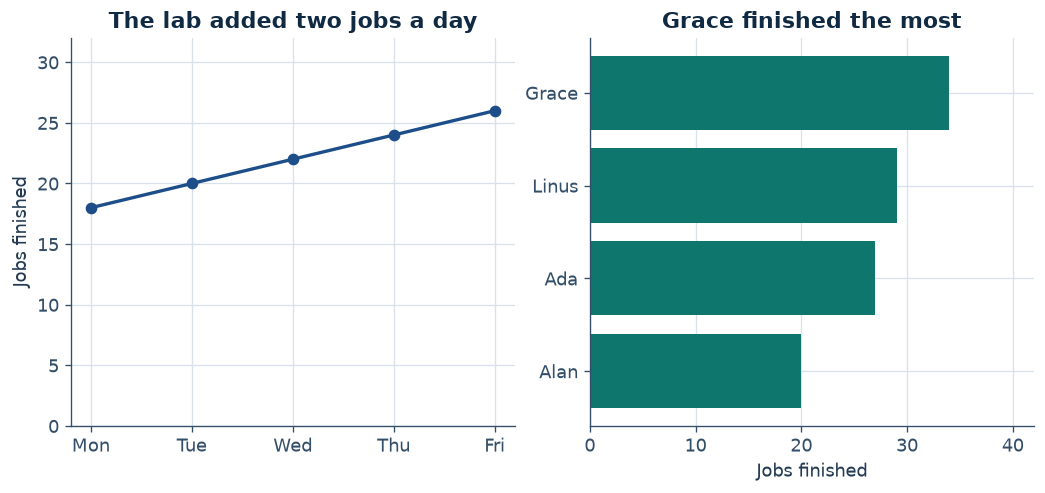

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# One page, two questions. Neither panel borrows the other's marks.
fig, panels = plt.subplots(1, 2, constrained_layout=True, figsize=(8.6, 4.0))
panels[0].plot(["Mon", "Tue", "Wed", "Thu", "Fri"], [18, 20, 22, 24, 26], color=BLUE, marker="o", linewidth=2)
panels[0].set_ylim(0, 32)
panels[0].set_ylabel("Jobs finished")
panels[0].set_title("The lab added two jobs a day")
panels[1].barh(["Alan", "Ada", "Linus", "Grace"], [20, 27, 29, 34], color=GREEN)
panels[1].set_xlim(0, 42)
panels[1].set_xlabel("Jobs finished")
panels[1].set_title("Grace finished the most")
assert len(panels[0].lines) == 1
assert len(panels[1].patches) == 4


## A pitfall

Stretching the pressure axis until its shape copies the temperature shape does not make a kilopascal into a degree. Small multiples work because each panel is free to use its own scale, and because you refuse to compare a slope in one panel with a slope in the other as if the units had cancelled.

## What to carry forward

One question per panel. Share the day axis when the days really are the same days. Temperature and pressure both peak on day $4$, and they move in opposite directions from day $1$ to day $2$.
